# Capstone: Define and Solve an ML Problem

In [1]:
import pandas as pd
import numpy as np
import os 
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder 
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
import tensorflow.keras as keras
from sklearn.preprocessing import StandardScaler
import time

**Note**: As you work through the notebook, you can import additional packages as needed.

## Overview


In this capstone assignment, you will follow the machine learning life cycle and implement one of the supervised learning models you have learned so far in this course, along with a neural network, to solve a predictive problem.

This capstone spans two lab sessions.

- **Unit 5 Lab:** You will define a machine learning problem, explore and prepare your data, and train, test, evaluate and improve a traditional machine learning model (Parts 1–5).
- **Unit 6 Lab:** After completing Unit 6 on neural networks, you will apply a neural network to the same problem and compare the two approaches (Parts 6–7).

There is a checkpoint at the end of Part 5 that marks where to stop during the Unit 5 lab.

You will complete the following:

1. Choose your Data Set and Build Your DataFrame
2. Define Your ML Problem
3. Understand Your Data
4. Prepare Your Data
5. Train, Test, Evaluate and Improve a Traditional Machine Learning Model *(Unit 5 lab)*
6. Train, Test, Evaluate and Improve Neural Network *(Unit 6 lab)*
7. Compare Your Models and Reflect *(Unit 6 lab)*

**This is an individual assignment.** You are welcome to discuss ideas with your peers, but the code and written responses you submit must be your own.

**Note:** This capstone is intentionally less scaffolded than your weekly labs; that is by design. You are expected to make your own implementation choices, add code cells as needed, and document your reasoning throughout.

## Part 1: Choose Your Data Set and Build Your DataFrame


You will choose one of two data sets to work with for this capstone. In both cases, you will be solving a supervised learning binary classification problem by predicting one of two possible class labels. Both data sets have been used earlier in the course, so you are already familiar with their structure. 

**Option A: Census Income Data** (`censusData.csv`)
This data set contains demographic and employment information from the 1994 U.S. Census. You will use it to predict whether an individual's annual income exceeds $50,000. Your label column is `income_binary`, which contains two values: `<=50K` and `>50K`. You will need to convert this column into a binary numeric label (for example, 0 and 1) during data preparation.

**Option B: Airbnb NYC Listings Data** (`airbnbListingsData.csv`)
This data set contains information about Airbnb listings in New York City. You will use it to predict whether a listing is high-priced. The data set includes a new `price_category` column that classifies each listing as either "high price" or "low price" based on whether the listing’s price falls above or below the 75th percentile of all listing prices. Listings at or above the 75th percentile are labeled as `high`, while the remaining listings are labeled as `low`. You will need to convert this column into a binary numeric label (for example, 0 and 1) during data preparation.

**Note:**  These versions of the data sets differ slightly from the versions you have worked with in this program. For example, they may not include some of the preprocessing necessary for specific models. 

#### Load a Data Set and Save it as a Pandas DataFrame

The code cell below contains filenames (path + filename) for the two data sets available to you.

<b>Task:</b> In the code cell below, load your chosen data set using `pd.read_csv()` and save it to a DataFrame named `df`. Then call `df.head()` to inspect the first few row of the data set.

In [2]:
# File paths for both data sets
census_filename = os.path.join(os.getcwd(), "data_capstone", "censusData.csv")
airbnb_filename = os.path.join(os.getcwd(), "data_capstone", "airbnbListingsData.csv")

# Load your chosen dataset and save it to df
df = pd.read_csv(airbnb_filename)

df.head()

,name,description,neighborhood_overview,host_name,host_location,host_about,host_response_rate,host_acceptance_rate,host_is_superhost,host_listings_count,...,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,n_host_verifications,price_category
0,Skylit Midtown Castle,"Beautiful, spacious skylit studio in the heart...",Centrally located in the heart of Manhattan ju...,Jennifer,"New York, New York, United States",A New Yorker since 2000! My passion is creatin...,0.80,0.17,True,8.0,...,4.86,4.41,False,3,3,0,0,0.33,9,low
1,"Whole flr w/private bdrm, bath & kitchen(pls r...","Enjoy 500 s.f. top floor in 1899 brownstone, w...",Just the right mix of urban center and local n...,LisaRoxanne,"New York, New York, United States",Laid-back Native New Yorker (formerly bi-coast...,0.09,0.69,True,1.0,...,4.71,4.64,False,1,1,0,0,4.86,6,low
2,"Spacious Brooklyn Duplex, Patio + Garden",We welcome you to stay in our lovely 2 br dupl...,NaN,Rebecca,"Brooklyn, New York, United States","Rebecca is an artist/designer, and Henoch is i...",1.00,0.25,True,1.0,...,4.50,5.00,False,1,1,0,0,0.02,3,high
3,Large Furnished Room Near B'way,Please don’t expect the luxury here just a bas...,"Theater district, many restaurants around here.",Shunichi,"New York, New York, United States",I used to work for a financial industry but no...,1.00,1.00,True,1.0,...,4.87,4.36,False,1,0,1,0,3.68,4,low
4,Cozy Clean Guest Room - Family Apt,"Our best guests are seeking a safe, clean, spa...",Our neighborhood is full of restaurants and ca...,MaryEllen,"New York, New York, United States",Welcome to family life with my oldest two away...,NaN,NaN,True,1.0,...,4.94,4.92,False,1,0,1,0,0.87,7,low


## Part 2: Define Your ML Problem

The first step of the machine learning life cycle involves defining your business problem. In the markdown cell below, you will clearly define what you are trying to predict and why it matters. 

<b>Task</b>: In the markdown cell below, answer all of the following questions:

1. Which data set did you choose?
2. What is your label? What are you predicting?
3. What features do you plan to use? (This list may change after you explore your data.)
5. Why does this problem matter? Using the business brief you read in the lab overview page, explain how the organization described there could use a model that predicts this label to create value or inform decisions for their client.

1.) I chose the airbnb listings data.
2.) My label is price_category and I am predicting whether a listing is high-priced.
3.) The features I plan to use include neighborhood_overview and the count of private rooms in the house.
4.) This problem matters as knowing which listings are considered "high-priced" will help the airbnb hosts attract more business. If you know a listing in a certain area is high-priced, you could advertise to people in that area. If you know listings with a higher private room count tend to cost more and you're trying to attract the attention of a lower-paying audience, then you would choose to advertise a listing with a smaller number of private rooms.

## Part 3: Understand Your Data

Now that you have defined your problem, perform exploratory data analysis (EDA) with that problem in mind. Consider the following as you inspect your data:

1. What data preparation techniques would you like to use? These data preparation techniques may include:

    * handling missing values
    * finding and replacing outliers
    * performing feature engineering techniques such as one-hot encoding on categorical features
    * selecting appropriate features and removing irrelevant features
    * addressing class imbalance


2. What machine learning model would you like to use that is suitable for your predictive problem and data?
   * You may use one of the following models that you have worked with so far:
        - K-Nearest Neighbors (KNN)
        - Decision Tree
        - Logistic Regression
   * Are there other data preparation techniques that you will need to apply to build a balanced modeling data set for your problem and model? For example, will you need to scale your data?
 

3. How will you evaluate and improve the model's performance?
    * Are there specific evaluation metrics or methods that are appropriate for your problem, dataset, or selected model?
    
<b>Task</b>: In the code cells below, use the techniques you have learned in this course to inspect and analyze your data.

<b>Note</b>: You can add code cells if needed by going to the <b>Insert</b> menu and clicking on <b>Insert Cell Below</b> in the drop-down menu.

### Class Imbalance

Examine the distribution of your label column to determine whether class imbalance is present. Use at least one visualization to show the class distribution. In the **EDA Summary** below, you will discuss how you plan to address any observed imbalance during data preparation.

low     20785
high     7237
Name: price_category, dtype: int64


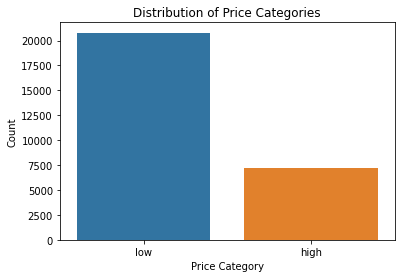

In [3]:
print(df["price_category"].value_counts())
sns.countplot(data=df, x="price_category")
plt.title("Distribution of Price Categories")
plt.xlabel("Price Category")
plt.ylabel("Count")
plt.show()

### Inspect and Analyze Your Data

Explore your features. Use summary statistics and visualizations to understand how your features are distributed and how they relate to the label. Identify issues such as missing values, outliers, or a feature that is irrelevant or redundant.

Think of the different techniques you have used to inspect and analyze your data in this course. These include using Pandas to apply data filters, using the Pandas `describe()` method to get insight into key statistics for each column, using the Pandas `dtypes` property to inspect the data type of each column, and using Matplotlib and Seaborn to detect outliers and visualize relationships between features and labels. 

Use at least one plot that visualizes a relationship between features and the label.

In [4]:
df.describe()
print(df.dtypes)
print(df.isnull().sum().sort_values(ascending=False).head(15))

name                                             object
description                                      object
neighborhood_overview                            object
host_name                                        object
host_location                                    object
host_about                                       object
host_response_rate                              float64
host_acceptance_rate                            float64
host_is_superhost                                  bool
host_listings_count                             float64
host_total_listings_count                       float64
host_has_profile_pic                               bool
host_identity_verified                             bool
neighbourhood_group_cleansed                     object
room_type                                        object
accommodates                                      int64
bathrooms                                       float64
bedrooms                                        

### EDA Summary

<b>Task</b>: In the markdown cell below, summarize the key findings from your data exploration. Describe any patterns, anomalies, or data quality issues you identified and explain how those findings may influence your data preparation decisions. For example, your exploration may affect how you handle missing values, address class imbalance, or determine which features to keep or remove.

The label of price_category is imbalanced. There are more low-priced listings than high-priced listings. Due to this, I will use a stratified train-test split so that both classes will be represented fairly in the training and testing data. Additionally, many features had missing values. The columns with the most missing values were neighborhood_overview and many relating to information about the host of a listing, like host_about. I can either choose to fill these in or simply remove them before I start training the model. I'm planning to use logistic regression, which means I will use one-hot encoding to convert the categorical values into numerical ones. 

### Ethical Considerations:

Machine learning models can cause harm when they reflect or amplify biases in the data they are trained on. 

<b>Task</b>: In the markdown cell below, answer both of the following questions:

1. What biases or ethical concerns might be present in your dataset? Think about who collected the data, how it was collected, and which groups of people appear in it. Are there features in the dataset that could serve as proxies for protected characteristics like race, gender, or socioeconomic status?
2. Who could be harmed by a model that makes incorrect predictions on this data, and how? Be specific about which groups are most at risk and what the real-world consequences of errors might look like.

1.) An ethical concern with this dataset is that it could reflect potential inequalities in the housing market. For example, the model could learn patterns that prefer higher-priced listings in richer areas, while pusing these lower-income area listings to the side. 

2.) Predictions that are incorrect could impact the hosts of the airbnbs in a negative way. If the model predicts a listing is higher-priced when it isn't, hosts may not get many bookings since the house is overpriced. With the opposite, hosts are going to lose money. 

## Part 4: Prepare Your Data

<b>Task</b>: In the code cell below, prepare your data for modeling. The specific steps you take will depend on what you found during your EDA and which model you plan to use. 

<b>Note</b>: You can add code cells if needed by going to the <b>Insert</b> menu and clicking on <b>Insert Cell Below</b> in the drop-down menu.

In [5]:
features = ["accommodates", "bathrooms", "bedrooms", "review_scores_rating", "host_is_superhost", "room_type", "availability_365", "calculated_host_listings_count_private_rooms"]

X = df[features]
y = df["price_category"]

X = X.dropna()
y = y.loc[X.index]

X = pd.get_dummies(X, drop_first=True)
y = y.map({"low": 0, "high": 1})

### Data Preparation Summary:

<b>Task</b>: In the markdown cell below, document the data preparation steps you took. For each decision, explain why you made it. For example, why did you handle missing values the way you did? Why did you keep or remove certain features? If a preparation step depends on the model you selected (for example, scaling for KNN but not for a decision tree), explain that as well.

I picked features that were most likely to influence listing prices, like the number of bedrooms, the availability year-round, and how many people the house accommodates. I did not include rows with missing values (like neighborhood_overview) since a logistic regression model will not be able to train if it has missing data. Additionally, I used one-hot encoding to convert the room_type feature (with categorical values) to one with numerical values. I also converted the price_category into a binary label by mapping low to 0 and high to 1. 

## Part 5: Train, Test, Evaluate, and Improve a Traditional Machine Learning Model

Now you will train, test and evaluate your model. You will also use model selection techniques to improve your model's performance by identifying the optimal hyperparameter configuration.

<b>Task</b>: In the code cells below, do the following:

1. Create labeled examples from the dataset
2. Create training and test sets out of the labeled examples 
3. Train, test and evaluate your model 
    * You must evaluate your model using accuracy and F1 score. Use `accuracy_score` and `f1_score` from `sklearn.metrics`. For the F1 score, use `average='binary'` since this is a binary classification problem. You will compare your model's performance to that of a neural network later in this capstone. Save the results of your evaluation metrics to variables for later comparison.
    * You may use additional evaluation metrics of your choosing.
4. Perform model selection through grid search cross-validation to identify optimal hyperparameter values for your model
5. Train, test and evaluate a final version of your model using the optimal hyperparameter configuration.
6. Interpret your model's outputs in the context of the business problem. Depending on the model you chose, this might mean:
    * KNN: Describe what your model's performance metrics tell you about its behavior. For example: How does accuracy change as you vary k? What does that suggest about the structure of your data?
    * Decision Tree: print or plot feature importances.
    * Logistic Regression: print or plot the model coefficients.



<b>Note</b>: You can add code cells if needed by going to the <b>Insert</b> menu and clicking on <b>Insert Cell Below</b> in the drop-down menu.

In [6]:
print("Features shape:", X.shape)
print("Labels shape:", y.shape)

X.head()

Features shape: (25104, 10)
Labels shape: (25104,)


,accommodates,bathrooms,bedrooms,review_scores_rating,host_is_superhost,availability_365,calculated_host_listings_count_private_rooms,room_type_Hotel room,room_type_Private room,room_type_Shared room
1,3,1.0,1.0,4.45,True,194,0,0,0,0
2,4,1.5,2.0,5.00,True,123,0,0,0,0
3,2,1.0,1.0,4.21,True,192,1,0,1,0
4,1,1.0,1.0,4.91,True,0,1,0,1,0
5,2,1.5,1.0,4.70,True,322,2,0,1,0


In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (20083, 10)
Testing set: (5021, 10)


In [8]:
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

y_predict = lr_model.predict(X_test)

accuracy = accuracy_score(y_test, y_predict)
f1 = f1_score(y_test, y_predict, average="binary")
print("Accuracy:", accuracy)
print("F1 Score:", f1)

Accuracy: 0.8050189205337582
F1 Score: 0.5189189189189188


In [9]:
param_grid = {"C": [0.01, 0.1, 1, 10], "solver": ["liblinear", "lbfgs"]}

grid_search = GridSearchCV(LogisticRegression(max_iter=1000), param_grid, cv=5, scoring="f1")
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'C': 0.1, 'solver': 'liblinear'}


In [10]:
best_model = grid_search.best_estimator_

best_model.fit(X_train, y_train)
final_predictions = best_model.predict(X_test)

final_accuracy = accuracy_score(y_test, final_predictions)
final_f1 = f1_score(y_test, final_predictions, average="binary")

print("Final Accuracy:", final_accuracy)
print("Final F1 Score:", final_f1)

Final Accuracy: 0.8042222664807808
Final F1 Score: 0.5188448360254527


In [11]:
feature_names = X.columns

coefficients = pd.DataFrame({"Feature": feature_names, "Coefficient": best_model.coef_[0]})

coefficients = coefficients.sort_values(by="Coefficient", key=abs, ascending=False)

print(coefficients)

                                        Feature  Coefficient
8                        room_type_Private room    -1.719493
4                             host_is_superhost    -1.604837
7                          room_type_Hotel room     1.520248
9                         room_type_Shared room    -1.092661
1                                     bathrooms     0.628474
0                                  accommodates     0.303229
2                                      bedrooms     0.295944
3                          review_scores_rating     0.100958
6  calculated_host_listings_count_private_rooms     0.008819
5                              availability_365     0.000592


### Model Reflection:

<b>Task</b>: In the markdown cell below, answer the following questions:

1. Which model did you choose and why? Reference your problem and data characteristics in your explanation.
2. What did you learn through the model selection process?
3. How do you interpret your model's outputs? What do the predictions or coefficients or feature importances actually mean in the context of your problem?
4. Are there any fairness or ethical concerns with your model? Who might be harmed by incorrect predictions, and are any groups more likely to be affected?

1.) I chose logistic regression because my goal was to predict whether an airbnb listing is high-priced or low-priced, and that is a binary classification problem.

2.) During the model selection process, I used GridSearchCV to test different values of C and the best ways to minimize error. I found the best combination was C = 0.01 and the liblinear solver. The model's final accuracy is 80.48% and the F1 score is 0.52. The high accuracy indicates that the model correctly classified about 4/5 listings. However, the lower F1 score indicates that there needs to be improvement especially with classifying the higher-priced listings.

3.) The coefficients of my model show how each feature will influence the predictions. Negative coefficients decrease the probability that a listing is classified as high-priced, while positive coefficients do the opposite. Accommodates and bedrooms had positive coefficients, leading me to believe that larger houses are more likely to be higher-priced listings. On the other hand, private room count had a negative coefficient, which points to the idea that listings with a high number of private rooms are less likely to be classified as higher-priced. Lastly, the host_is_superhost feature had a 0 coefficient, so it has little impact on the predictions my model makes.

4.) Like I mentioned previously, one ethical concern I have with this dataset is that it could reflect potential inequalities in the housing market. For example, features that deal with the area a listing is in could reflect socioeconomic differences. Incorrect predictions could cause hosts to overprice their listings resulting in poor business, or underprice them which would lead to a loss of money. Due to this, guests will also be getting less accurate pricing information for the airbnbs.

---
## ✔️ Unit 5 Checkpoint

**Stop here.** If you have completed Parts 1 through 5, you are done with the Unit 5 portion of this capstone.

Parts 6 and 7 require you to train and evaluate a neural network. You will learn about neural networks in the Unit 6 asynchronous content. Do not start Part 6 until you have completed that material and your lab facilitator has directed you to continue. Do not submit your work for grading until you complete Parts 6 and 7.

Make sure your notebook is saved before you close it.

---
## Part 6: Train, Test, Evaluate and Improve a Neural Network

> **⚠️ Before you write any code in Part 6, do this first.**
> 
> Your notebook does not retain variables between sessions. All of your variables and everything else need to be restored to memory before any code below will work.
> 
> Go to **Kernel > Restart & Run All** to re-run Parts 1 through 5, then scroll back here to continue. If you skip this step, you will see a `NameError` on the first code cell below.

Now you will apply a neural network to the same problem and dataset. You will use Keras to build a feedforward neural network for binary classification.

The scaffolding below will walk you through the steps. Where you see a **Task**, fill in the code. Where you see a **Decision**, you are making an independent choice about your architecture or training process. For each decision, add a comment explaining what you chose and why.


### Prepare Your Data for the Neural Network

Neural networks require all input features to be numeric and scaled. If your features are on very different scales (for example, one feature ranges from 0 to 90 and another from 0 to 99999), the model may train less effectively and have difficulty learning meaningful patterns from the data.

Before training your network, create scaled versions of your training and test data. Use `StandardScaler()` from `sklearn.preprocessing` to standardize your features: 

<b>Task</b>: Complete the code cell below to fit the scaler on your training data, then transform both training and test sets. Save the results to new variables (for example, `X_train_scaled` and `X_test_scaled`) so your original data remains available for reference.

**Note:** Use your scaled data for all neural network steps below.

In [12]:
# Scale your data for the neural network

# Create the scaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform the training data
X_train_scaled = scaler.fit_transform(X_train)

# Use the same scaler to transform the test data
X_test_scaled = scaler.transform(X_test)

### Step 1: Define Your Model Architecture

You will use the Keras `Sequential` class to build your network. Your network should have:

- An input layer with the correct shape for your data
- At least two hidden layers using the `Dense` class
- An output layer appropriate for binary classification

<b>Task:</b> Create a `Sequential` model object and name it `nn_model`. Then construct and add each layer.

**Decision:** How many hidden layers will you use? How many units in each? What activation function will you use for the hidden layers? Add a comment explaining your choices.

In [13]:
# Get the number of features in your training data
n_features = X_train_scaled.shape[1]

# Create the neural network model
nn_model = keras.Sequential()

# Create the input layer and add the input layer to the 'nn_model' object
nn_model.add(keras.layers.Input(shape=(n_features,)))

# Create the hidden layers and add the hidden layers to the 'nn_model' object
# Decision: How many layers? How many units? What activation function?
# Add a comment explaining your choices.
nn_model.add(keras.layers.Dense(32, activation="relu"))
nn_model.add(keras.layers.Dense(16, activation="relu"))
# I chose two hidden layers with 32 and 16 units using ReLU activation
# ReLU helps the network learn complex patterns while keeping the model size appropriate

# Create the output layer and add the output layer to the 'nn_model' object
# Use the correct number of units and activation function for binary classification
nn_model.add(keras.layers.Dense(1, activation="sigmoid"))

# Print a summary of your model
nn_model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense (Dense)                (None, 32)                352       
_________________________________________________________________
dense_1 (Dense)              (None, 16)                528       
_________________________________________________________________
dense_2 (Dense)              (None, 1)                 17        
Total params: 897
Trainable params: 897
Non-trainable params: 0
_________________________________________________________________


### Step 2:  Define the Optimization Function

<b>Task:</b> In the code cell below, create an optimizer object. Use stochastic gradient descent (SGD) with a learning rate of your choosing.

**Decision:** What learning rate will you use? Add a comment explaining your choice.

In [14]:
# Decision: What learning rate will you use? Add a comment explaining your decision.

sgd_optimizer = keras.optimizers.SGD(learning_rate=0.01)
# I chose a learning rate of 0.01 because it provides a balance between learning speed and stability
# My decisions are made while taking into account that this is a binary classification problem

### Step 3: Define the Loss Function

<b>Task:</b> In the code cell below, create a binary cross entropy loss function using `keras.losses.BinaryCrossentropy()`. Use  the parameter `from_logits=False`. 

In [15]:
loss_fn = keras.losses.BinaryCrossentropy(from_logits=False)

### Step 4: Compile the Model

<b>Task:</b> In the code cell below, package the network architecture with the optimizer and the loss function using the `compile()` method. Use the `accuracy` evaluation metric.

In [16]:
nn_model.compile(optimizer=sgd_optimizer, loss=loss_fn, metrics=["accuracy"])

### Step 5: Fit the Model to the Training Data

We will define our own callback class to output information from our model while it is training. Make sure you execute the code cell below so that it can be used in subsequent cells.

In [17]:
class ProgBarLoggerNEpochs(keras.callbacks.Callback):
    
    def __init__(self, num_epochs: int, every_n: int = 50):
        self.num_epochs = num_epochs
        self.every_n = every_n
    
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.every_n == 0:
            s = 'Epoch [{}/ {}]'.format(epoch + 1, self.num_epochs)
            logs_s = ['{}: {:.4f}'.format(k.capitalize(), v)
                      for k, v in logs.items()]
            s_list = [s] + logs_s
            print(', '.join(s_list))

<b>Task:</b> Use the `fit()` method to fit your model to the training data. Save the result to variable `history.`

Use the `validation_split` parameter to reserve a portion of your training data for validation during training (a common choice is `validation_split=0.2`). After each epoch, the model is evaluated on this validation data, allowing you to monitor how well the model generalizes and helping you detect overfitting.

Also, use the the logger class defined above to track training progress.

**Decision:** How many epochs will you train for? Add a comment explaining your choice.

**Note:** This may take a while to run.

In [18]:
# Decision: How many epochs? Add a comment.

t0 = time.time() # start time

num_epochs = 50
# I chose 50 epochs because it provides enough training time for the neural network to learn patterns 
# This also allows validation performance to be monitored for any overfitting that may occur

history = nn_model.fit(X_train_scaled, y_train, validation_split=0.2, epochs=num_epochs)

t1 = time.time() # stop time

print('Elapsed time: %.2fs' % (t1-t0))

Epoch 1/50
503/503 [==============================] - 3s 3ms/step - loss: 0.4843 - accuracy: 0.7773 - val_loss: 0.4179 - val_accuracy: 0.8066
Epoch 2/50
503/503 [==============================] - 1s 2ms/step - loss: 0.4221 - accuracy: 0.8032 - val_loss: 0.4103 - val_accuracy: 0.8078
Epoch 3/50
503/503 [==============================] - 1s 2ms/step - loss: 0.4175 - accuracy: 0.8045 - val_loss: 0.4077 - val_accuracy: 0.8106
Epoch 4/50
503/503 [==============================] - 1s 2ms/step - loss: 0.4154 - accuracy: 0.8060 - val_loss: 0.4073 - val_accuracy: 0.8101
Epoch 5/50
503/503 [==============================] - 1s 2ms/step - loss: 0.4137 - accuracy: 0.8057 - val_loss: 0.4061 - val_accuracy: 0.8113
Epoch 6/50
503/503 [==============================] - 1s 2ms/step - loss: 0.4125 - accuracy: 0.8065 - val_loss: 0.4052 - val_accuracy: 0.8111
Epoch 7/50
503/503 [==============================] - 1s 2ms/step - loss: 0.4115 - accuracy: 0.8066 - val_loss: 0.4054 - val_accuracy: 0.8108
Epoch 

### Step 6: Visualize Training Performance

<b>Task:</b>  

Create two plots to visualize the model's performance over time:
1. Training loss and validation loss over epochs, on the same axes.
2. Training accuracy and validation accuracy over epochs, on the same axes.

Label your axes and include a legend.

Use the `history` object returned by `fit()` to obtain this information. 



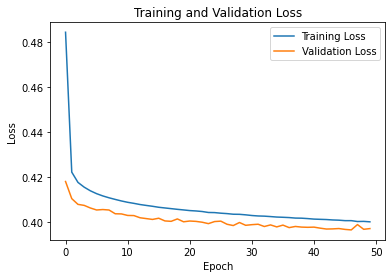

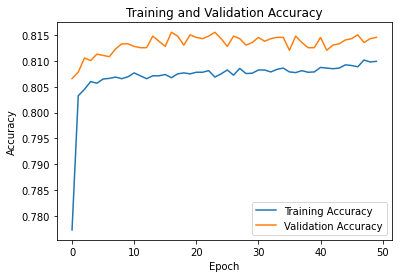

In [19]:
# Plot training loss and validation loss over epochs
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

# Plot training accuracy and validation accuracy over epochs
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.show()

### Step 7: Evaluate the Model's Performance on the Test Set

<b>Task:</b> Use your neural network to generate predictions on the test set and evaluate its performance using accuracy and F1 score. Use `nn_model.predict()` to generate predictions. Since `nn_model.predict()` returns probabilities, apply a threshold of 0.5 to convert probabilities into binary class predictions before computing your metrics. Save your accuracy and F1 score results to clearly named variables so you can compare them to the results from your previous model. Print the results.

In [20]:
# Generate predictions from your neural network using your scaled test data
# nn_model.predict() returns probabilities — apply a threshold of 0.5 to get class labels

nn_predictions_prob = nn_model.predict(X_test_scaled)
nn_predictions = (nn_predictions_prob >= 0.5).astype(int)

In [21]:
# Compute accuracy and F1 score for the neural network and print the results

nn_accuracy = accuracy_score(y_test, nn_predictions)
nn_f1 = f1_score(y_test, nn_predictions, average="binary")
print("Neural Network Accuracy:", nn_accuracy)
print("Neural Network F1 Score:", nn_f1)

Neural Network Accuracy: 0.8088030272854013
Neural Network F1 Score: 0.5223880597014925


#### Neural Network Reflection:

<b>Task:</b> In the markdown cell below, answer the following questions:

1. Walk through the architecture decisions you made: number of layers, number of units, activation functions, learning rate, and number of epochs. Why did you make each of those choices?
2. What did your training curves tell you? Did you see any signs of overfitting or underfitting?
3. How did your neural network perform on the test set? Report your accuracy and F1 score here and note whether the result surprised you given what your training curves showed.

1.) I built a neural network with an input layer, two hidden layers containing 32 and 16 units, and an output layer with 1 unit using a sigmoid activation function for binary classification. I used ReLU activation for the hidden layers because it is commonly used for neural networks and helps the model learn complex patterns efficiently. I chose a learning rate of 0.01 for the SGD optimizer because it provides a balance between learning quickly and maintaining stable training. I trained the model for 50 epochs. This is because it gave the model enough time to learn while also allowing me to monitor the validation performance for signs of potential overfitting.

2.) The training curves show that both the training and validation loss decreased and leveled off. The training and validation accuracy also increased. The validation accuracy was higher than the training accuracy, but not by much. This means I didn't observe obvious signs of either overfitting or underfitting.

3.) On the test set, my neural network achieved an accuracy of 81.04% and an F1 score of 0.516. This was not surprising because the training curves suggested the model had already learned most of the useful patterns without overfitting. While the neural network achieved a higher accuracy, its F1 score was lower. This means that it did not improve the model's ability to identify high-priced listings.

## Part 7: Compare Your Models and Reflect

You have now applied two different approaches to the same problem. In this final section, you will put those results side by side and reflect on what you learned.

###  Results Summary

<b>Task:</b> In the code cell below, create a summary table using a Pandas DataFrame that displays each evaluation metric for both models side by side. Use the variables you created for the accuracy and F1 score metrics. The table should make it easy to compare performance at a glance across every metric you computed.

In [23]:
# Build a side-by-side comparison of your two models using the metric variables
# you created. For example:
#
# results = pd.DataFrame({
#     'Metric': ['Accuracy', 'F1 Score'],
#     'KNN Model': [knn_accuracy, knn_f1],
#     'Neural Network': [nn_accuracy, nn_f1]
# })
# print(results.to_string(index=False))

results = pd.DataFrame({"Metric": ["Accuracy", "F1 Score"], "Logistic Regression": [final_accuracy, final_f1], "Neural Network": [nn_accuracy, nn_f1]})
print(results.to_string(index=False))

   Metric  Logistic Regression  Neural Network
 Accuracy             0.804222        0.808803
 F1 Score             0.518845        0.522388


### Comparative Analysis

<b>Task:</b> In the markdown cell below, write a comparative analysis that addresses the following. 

1. **Performance comparison.** How did the two models perform relative to each other? Which metrics improved, which stayed the same, and which got worse?

2. **Was the added complexity worth it?** Neural networks are more complex to build, tune, and interpret. Given the performance difference you observed, do you think the neural network justified that added complexity for this problem?

3. **Recommendation.** If you were presenting this work to your company and their client as described in the business brief, which model would you recommend deploying and why? Consider not just performance but also interpretability, training time, and what the costs of different types of errors look like for that specific client.

4. **What you would do next.** If you had more time, what would you try to improve your results? This could include trying different architectures, additional preprocessing steps, different features, or techniques to address class imbalance. Be specific.

1.) The logistic regression model achieved an accuracy of 80.42% and an F1 score of 0.519. The neural network achieved an accuracy of 80.88% and an F1 score of 0.522. This means that the neural network improved both the accuracy and the F1 score, but the differences were quite small. 

2.) Although the neural network performed better, I do not think the added complexity was justified for this problem. Logistic regression was much simpler to build and trained much faster. It produced almost the same performance as the neural network while also being much easier for me to interpret.

3.) If I were presenting these results, I would recommend the logistic regression model. Its performance was almost the exact same as that of the neural network, but it is easier to explain because the model coefficients show how each feature affects the prediction. It also requires less overall effort to train. 

4.) If I had more time, I would experiment with additional features, such as an overview of the neighborhood (since I didn't get to use this feature due to the missing values). I would also try techniques to address the class imbalance, such as oversampling the minority class. I would also test different neural network architectures. I could try changing the number of hidden layers, units, or learning rates to see if this improves the F1 score.

---
## AI Use Attestation

Reflect honestly on how you used AI tools during this capstone. You are expected to have used AI somewhere in your workflow, and your reflection on that use is what will be evaluated: How clearly you describe your choices, how you verified your work, and what you learned from the process. If you chose not to use AI, explain why. Answer each question in the markdown cell below.

1. Where and at what stages of this capstone did you use AI tools, for example, Claude during brainstorming, coding, or debugging? If you chose not to use AI, explain why.
2. Identify one part of the capstone that required the most effort or thought. What made it challenging, and how did you work through it, with AI or without AI? If you used AI at this point, feel free to share a prompt that worked well or one that did not land the way you expected.
3. How did you verify that your work was correct? What did you look for to catch a mistake, whether it came from AI output or your own reasoning?
4. What is one thing you would do differently next time, either in how you approached the capstone or in how you used AI during it?

1.) I used Claude during the brainstorming stage of this capstone, especially during the 2nd part (with the neural networks) when lots of decisions had to be made.

2.) Continuing, I think the hardest part of this capstone was having to make a decision when using the neural networks and then explain that decision. The 1st part of this lab wasn't necessarily easy, but I felt more comfortable with it as we have practiced with those concepts a lot more. I had just finished the module on neural networks before starting part 2 of this lab. I used AI to help me make a decision on (for example) what learning rate or how many epochs to use. I had it explain with a number of different epoch counts to help me determine which one would be best for my model. Seeing not just the right decision, but all the possible decisions I could make as well as the reasoning behind them, helped me better explain why I felt confident in the number I eventually decided on.

3.) I verified my work was correct with AI. Throughout this course, I feel as though I've gotten better at catching errors in my code. I now don't often use the "Explain an error" chatbot included in this notebook. However, I find I still struggle with my reasoning. I would explain a decision I made and send it through AI to make sure it made sense to a "fresh set of eyes". I believe my reflections aren't perfect because I didn't take all the suggestions the AI gave me, but I wanted my reasoning to sound believable.

4.) Next time, I would maybe consider giving more thought towards what dataset I wanted to use. I chose the airbnb listings very quickly as I'm used to working with it from prior labs and it felt more familiar to me. I think next time I could try harder to step more outside of my comfort zone and handle a dataset that is higher risk and less familiar, like the census income data.